<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_1_Classification_Basics/18_1_3_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Classification: Examples and Practice
## Applying Concepts from Notebooks 1 & 2

**Author:** Brad Sheese

---

## Introduction

This notebook demonstrates all the concepts learned in:
- **Notebook 1 (Classification Foundations):**    
    - Class imbalance
    - XGBoost
    - feature importance
    - hard vs soft predictions
- **Notebook 2 (Confusion Matrix):**
    - Precision
    - recall
    - F1-score
    - classification report

We'll apply these concepts to a new dataset: the Adult Census Income dataset.

The question:
* Can we predict whether someone earns more than $50,000 per year based on census data?

This is a classic ML problem, similar to credit default prediction but applied to income classification.

## Section 1: Load and Explore the Data

We'll load the Adult Census Income dataset from OpenML. This data was extracted from the 1994 Census database.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import re

print("Loading Adult Census Income dataset...")
data = fetch_openml(name='adult', version=2, as_frame=True)
df = data.frame

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Loading Adult Census Income dataset...
Dataset shape: (48842, 15)

First few rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Examine the Target Variable

The target variable is 'class' with values '>50K' and '<=50K' (stored in 'class' column). Let's examine the class distribution.

Target variable distribution:
class
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64


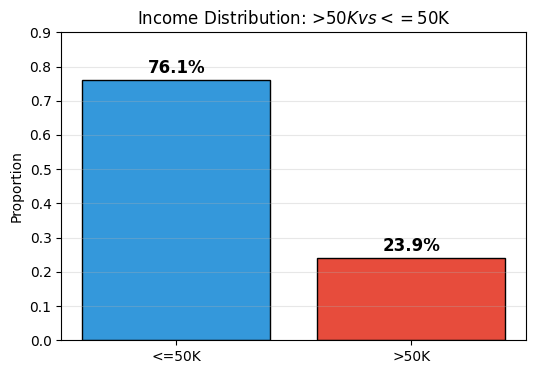


Naive baseline accuracy (always predict '<=50K'): 76.1%


In [ ]:
# Examine target variable
print("Target variable distribution:")
class_counts = df['class'].value_counts(normalize=True)
print(class_counts)

# Visualize
plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=['#3498db', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylabel('Proportion')
plt.title('Income Distribution: >$50K vs <=$50K')
plt.ylim(0, 0.9)
plt.grid(axis='y', alpha=0.3)
plt.show()

baseline = (df['class'] == '<=50K').mean()
print(f"\nNaive baseline accuracy (always predict '<=50K'): {baseline:.1%}")

## Section 2: Data Preparation

Now we prepare the data for XGBoost:
1. Convert target to binary (1 = '>50K', 0 = '<=50K')
2. One-hot encode categorical features
3. Stratified train-test split

In [ ]:
# 1. Convert target to binary: >50K = 1 (high income), <=50K = 0
y = (df['class'] == '>50K').astype(int) # this creates a boolean mask off the class column, then converts that mask to int
X = df.drop(columns=['class'])

# 2. One-hot encode categorical features
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")
print(cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Clean column names for XGBoost compatibility, you do not need to know how this works
X_encoded.columns = [re.sub(r"[<>[\]]", "_", col) for col in X_encoded.columns]

# 3. Train-test split with stratification. Why do we need the stratification?
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nOriginal features: {X.shape[1]}")
print(f"Encoded features: {X_encoded.shape[1]}")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set class ratio: {y_test.mean():.1%} high income, {(1-y_test.mean()):.1%} low income")

Categorical columns to encode: 8
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Original features: 14
Encoded features: 97
Training set size: 34189
Test set class ratio: 23.9% high income, 76.1% low income


## Section 3: Train XGBoost Model

We use `scale_pos_weight` to handle the class imbalance (~76% low income, ~24% high income).

In [ ]:
# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model training complete!")

scale_pos_weight: 3.18
Model training complete!


## Section 4: Confusion Matrix Analysis

Let's build and interpret the confusion matrix,  this shows exactly where our predictions are correct and where they're wrong.

--- Confusion Matrix Breakdown ---
True Negatives  (TN) — Correctly predicted '<=50K': 9030
True Positives   (TP) — Correctly predicted '>50K':  3057
False Positives (FP) — Wrongly predicted '>50K':    2117
False Negatives (FN) — Wrongly predicted '<=50K':   449


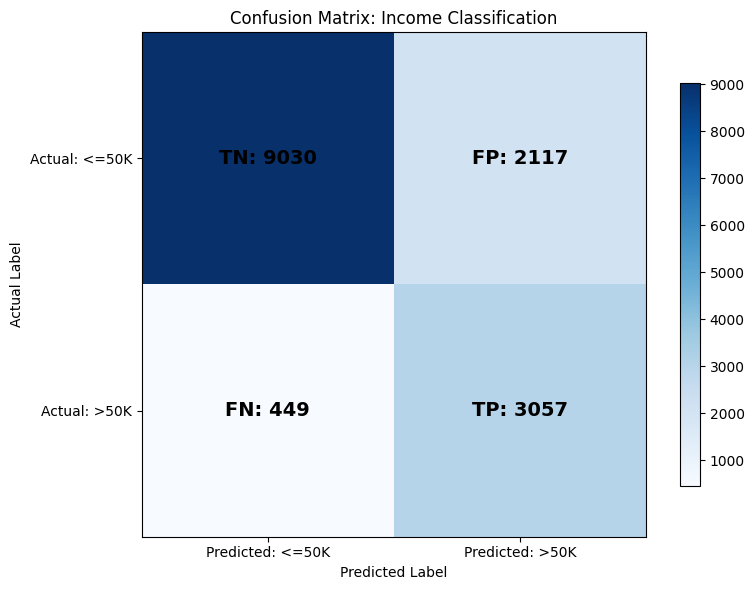

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"--- Confusion Matrix Breakdown ---")
print(f"True Negatives  (TN) — Correctly predicted '<=50K': {tn}")
print(f"True Positives  (TP) — Correctly predicted '>50K':  {tp}")
print(f"False Positives (FP) — Wrongly predicted '>50K':    {fp}")
print(f"False Negatives (FN) — Wrongly predicted '<=50K':   {fn}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: <=50K', 'Predicted: >50K'])
ax.set_yticklabels(['Actual: <=50K', 'Actual: >50K'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
ax.set_title('Confusion Matrix: Income Classification')

labels = [
    [f'TN: {tn}', f'FP: {fp}'],
    [f'FN: {fn}', f'TP: {tp}']
]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Business Interpretation

Let's pretend someone has asked us to use this dataset to identify customers for premium products/services (i.e., find wealthier folks to sell them expensive things they probably don't need). In this income prediction context:
- **False Positives (FP):** We predicted high income, but the person actually earns <=50K. In a business context, this might mean incorrectly targeting someone for a premium product and are wasting our marketing budget.
- **False Negatives (FN):** We predicted low income, but the person actually earns >50K. This might mean missing someone who would qualify for a premium service. No doubt they are living a sadder life now missing out on our expensive products/services, and we are, of course, missing out on profit.

The cost of each type of error depends on your use case. Our marketing budget is definitely not infinite, so we need to think carefully about what kind of errors we are more comfortable making.

## Section 5: Precision, Recall, and F1-Score


In [ ]:
# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"Accuracy:  {accuracy*100:.1f}% (Overall correctness)")
print(f"Precision: {precision*100:.1f}% (When we predict '>50K', we're right this often)")
print(f"Recall:    {recall*100:.1f}% (We catch this % of actual high earners)")
print(f"F1-Score:  {f1*100:.1f}% (Balance between precision and recall)")
print(f"\nNaive baseline: {baseline*100:.1f}%")
print(f"Improvement over baseline: {(accuracy-baseline)*100:.1f} percentage points")

--- Model Performance ---
Accuracy:  82.5% (Overall correctness)
Precision: 59.1% (When we predict '>50K', we're right this often)
Recall:    87.2% (We catch this % of actual high earners)
F1-Score:  70.4% (Balance between precision and recall)

Naive baseline: 76.1%
Improvement over baseline: 6.4 percentage points


### Full Classification Report

The classification report shows per-class metrics plus averages.

In [ ]:
print(classification_report(y_test, y_pred, target_names=['<=50K (0)', '>50K (1)']))

              precision    recall  f1-score   support

   <=50K (0)       0.95      0.81      0.88     11147
    >50K (1)       0.59      0.87      0.70      3506

    accuracy                           0.82     14653
   macro avg       0.77      0.84      0.79     14653
weighted avg       0.87      0.82      0.83     14653



**Key observations:**
- The '>50K' (class 1) has lower precision and recall - the model has a harder time identifying high-income individuals
- Macro average treats both classes equally; weighted average accounts for class imbalance
- Notice how weighted average (83%) is closer to accuracy than macro average (79%)

## Section 6: Feature Importance

Let's see which census features matter most for predicting income level.

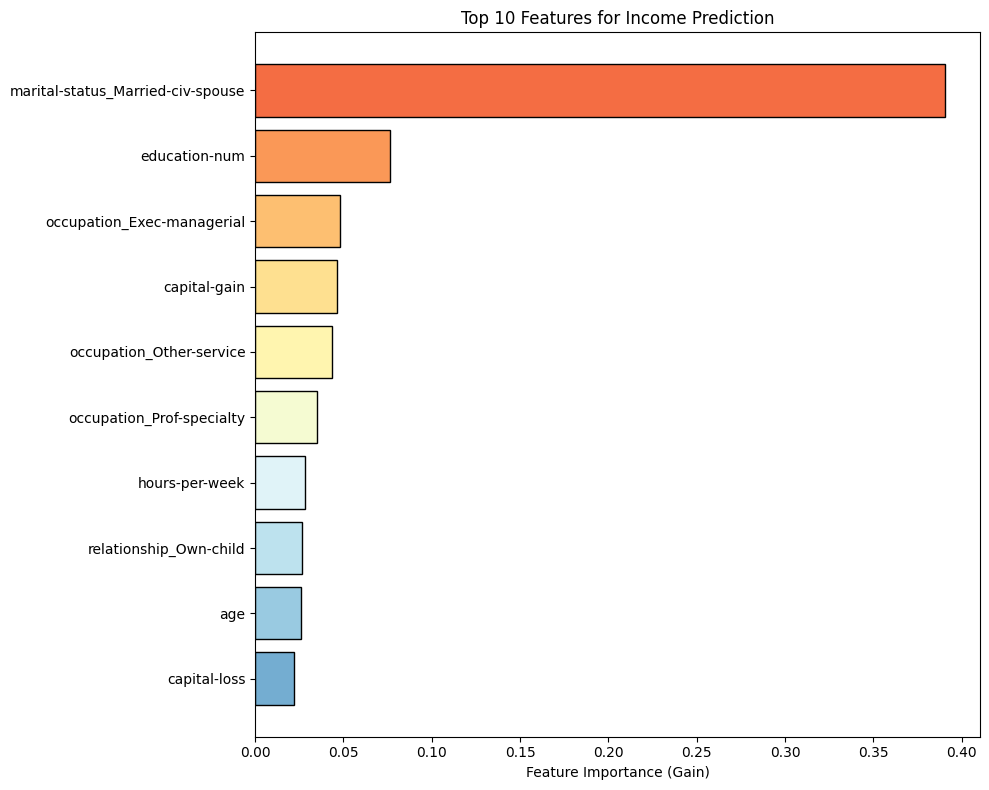


Top 5 Most Important Features:
  marital-status_Married-civ-spouse        0.3908
  education-num                            0.0766
  occupation_Exec-managerial               0.0479
  capital-gain                             0.0463
  occupation_Other-service                 0.0436


In [ ]:
# Extract feature importance
importance_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize top 10 features
plt.figure(figsize=(10, 8))
top_10 = importance_df.head(10)
colors = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(top_10)))
plt.barh(top_10['Feature'], top_10['Importance'], color=colors, edgecolor='black')
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 10 Features for Income Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for _, row in importance_df.head(5).iterrows():
    print(f"  {row['Feature']:<40} {row['Importance']:.4f}")

### Interpreting Feature Importance

The top features tell us which census variables are most predictive of income level. However, like all tree-based importance scores, this tells us which features matter, not how they affect predictions (positive or negative direction).

For example, 'capital_gain' might be highly important, but does higher capital gain mean higher or lower income? If you know what capital gains are you'd strongly suspect higher, but you'd need additional analysis (like partial dependence plots, which we are not going to get into) to determine that.

## Section 7: Probability Distribution Analysis

Let's visualize the overlap between predicted probabilities for each actual class, this shows where our model is uncertain.

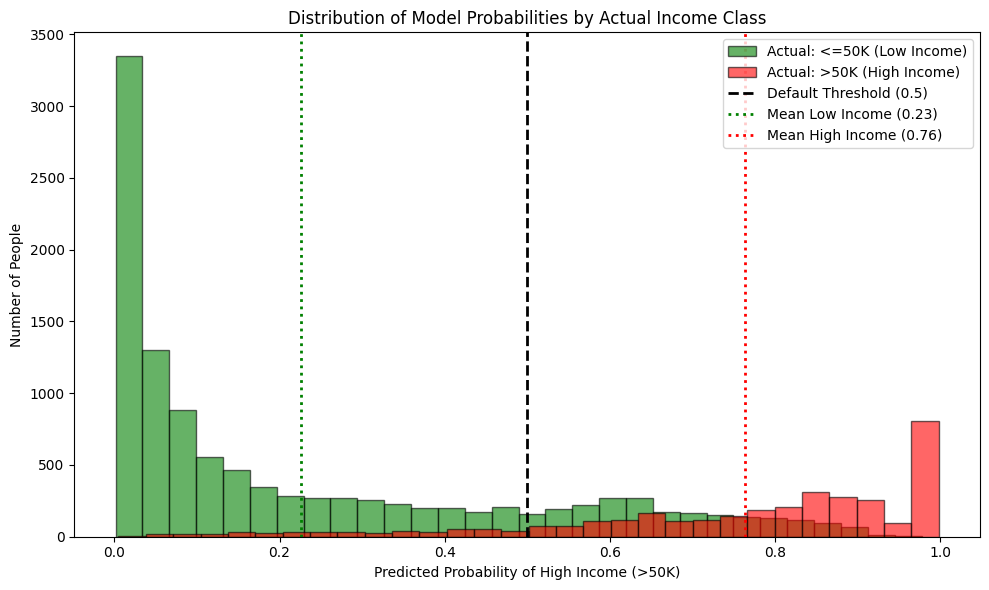


Overlap Analysis at 0.5 threshold:
  12.8% of actual high earners scored below 0.5 (missed/False Negatives)
  19.0% of actual low earners scored above 0.5 (false alarms/False Positives)


In [ ]:
# Calculate overlap statistics
fn_rate = ((y_proba[y_test==1] < 0.5).sum() / (y_test==1).sum()) * 100
fp_rate = ((y_proba[y_test==0] >= 0.5).sum() / (y_test==0).sum()) * 100

# Visualize probability distributions
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(y_proba[y_test==0], bins=30, alpha=0.6, label='Actual: <=50K (Low Income)', color='green', edgecolor='black')
ax.hist(y_proba[y_test==1], bins=30, alpha=0.6, label='Actual: >50K (High Income)', color='red', edgecolor='black')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Default Threshold (0.5)')

# Add mean probability lines
mean_low = y_proba[y_test==0].mean()
mean_high = y_proba[y_test==1].mean()
ax.axvline(x=mean_low, color='green', linestyle=':', linewidth=2, label=f'Mean Low Income ({mean_low:.2f})')
ax.axvline(x=mean_high, color='red', linestyle=':', linewidth=2, label=f'Mean High Income ({mean_high:.2f})')

ax.set_xlabel('Predicted Probability of High Income (>50K)')
ax.set_ylabel('Number of People')
ax.set_title('Distribution of Model Probabilities by Actual Income Class')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nOverlap Analysis at 0.5 threshold:")
print(f"  {fn_rate:.1f}% of actual high earners scored below 0.5 (missed/False Negatives)")
print(f"  {fp_rate:.1f}% of actual low earners scored above 0.5 (false alarms/False Positives)")

### Reading the Probability Distribution

- The **green distribution** (actual low income) is shifted left. The model assigns them low probabilities of high income.
- The **red distribution** (actual high income) is shifted right. The model assigns them higher probabilities.
- The gap between the two mean probabilities shows how well the model separates the two groups.
- The overlap around 0.5 is where the model is uncertain. This is where misclassifications happen.

In the next notebook (ROC/AUC), we'll learn how to move the threshold to optimize for different business needs.

## Section 8: Summary

This notebook demonstrated all key concepts from Notebooks 1 & 2 using the Adult Census Income dataset:

### Concepts Covered:

| Concept | Notebook 1 | Notebook 2 | This Notebook |
|---------|------------|------------|----------------|
| Class Imbalance | ✓ | ✓ | ✓ (76/24 split) |
| Naive Baseline | ✓ | ✓ | ✓ |
| XGBoost + scale_pos_weight | ✓ | ✓ | ✓ |
| One-Hot Encoding | ✓ | — | ✓ |
| Stratified Split | ✓ | — | ✓ |
| Confusion Matrix | — | ✓ | ✓ |
| Precision/Recall/F1 | — | ✓ | ✓ |
| Feature Importance | ✓ | — | ✓ |
| Probability Distributions | ✓ | — | ✓ |

### Key Takeaways:
1. **Accuracy can be misleading** on imbalanced data - always check precision/recall
2. **Confusion matrix** shows exactly where errors occur
3. **F1-score** balances precision and recall
4. **Feature importance** tells us what matters, but not how
5. **Probability distributions** show model uncertainty